## Lomb-Scargle Analysis Code for TGP Asteroids 2 (2025-26)

In [1]:
# Necessary imports
import numpy as np
import matplotlib.pyplot as plt
from astropy.timeseries import LombScargle

In [2]:
import emcee
import corner

In [3]:
# This is hardcoded in, sorry fellas
# Can't use the files off of GitHub, so if you want to run this, download the files in the folder and replace the file paths accordingly, much love

data_file1 = "C:/Users/Matylda/Documents/TGP/Data/data_3ast_4star"
data_file2 = "C:/Users/Matylda/Documents/TGP/Data/data_5ast_5star"

### Inspect the data files (here, just 3 pix asteroid, 4 pix standard stars - scroll down for the second file)

In [4]:
def read_data(file_path):

    # Read the data file in
    data = np.loadtxt(data_file1, skiprows=1, delimiter="|")

    # Extract data
    times = data[:, 0] # This is in hours 
    magnitudes = data[:, 1]  
    mag_errors = data[:, 2]  

    # Need to convert to days
    times_days = times / 24.0


    plt.figure(figsize=(12, 4))
    plt.errorbar(times, magnitudes, yerr=mag_errors, fmt='o', alpha=0.6, capsize=3, color='black')
    plt.xlabel('Time (hours)')
    plt.ylabel('Relative Magnitude')
    plt.gca().invert_yaxis()
    plt.title('Light Curve')
    plt.show()

    return times, times_days, magnitudes, mag_errors

### Now, let's actually get the lightcurve period

Here, I'm going to use LombScargle from Astropy to get the estimate for the best period, which then I'm going to use as a prior for emcee to get a better estimate + error on the estimate. Given the lightcurve is double peaked, I'm also going to estimate the amplitudes of the fundamental and the second harmonic. This should be an upgrade over just using LombScargle + FWHM uncertainty.

In [ ]:
def lomb_scargle(times, times_days, mags, mag_errors):

    ls = LombScargle(times_days, mags, mag_errors)

    frequency, power = ls.autopower(minimum_frequency=1.0,
                                    maximum_frequency=24.0, 
                                    samples_per_peak=10)

    # Find the best period from Lomb-Scargle
    best_frequency = frequency[np.argmax(power)]
    best_period = 1 / best_frequency

    print(f"Lomb-Scargle Best period: {best_period:.4f} days ({best_period*24:.2f} hours)")
    print(f"Peak power: {power.max():.4f}")

    # FWHM uncertainty
    peak_power = power.max()
    peak_idx = np.argmax(power)
    half_max = peak_power / 2

    left_idx = peak_idx
    while left_idx > 0 and power[left_idx] > half_max:
        left_idx -= 1

    right_idx = peak_idx
    while right_idx < len(power) - 1 and power[right_idx] > half_max:
        right_idx += 1

    freq_width = frequency[right_idx] - frequency[left_idx]
    period_uncertainty_fwhm = freq_width / (best_frequency**2)

    print(f"Lomb-Scargle Period uncertainty (FWHM): +/- {period_uncertainty_fwhm*24:.2f} hours")
    
    false = ls.false_alarm_probability(power.max())
    print(f"False alarm probability: {false:.4e}")
    
    # For a DOUBLE-PEAKED lightcurve, use a double sinusoid model
    def double_sinusoid_model(t, theta):
        """
        theta = [period, amp1, amp2, phase1, phase2, mag_offset]
        Two harmonics: fundamental + first harmonic (2× frequency)
        """
        period, amp1, amp2, phase1, phase2, mag_offset = theta
        freq = 1.0 / period
        model = mag_offset
        model += amp1 * np.sin(2 * np.pi * freq * t + phase1)
        model += amp2 * np.sin(4 * np.pi * freq * t + phase2)  # 2× frequency
        return model
    
    # Log-likelihood function
    def log_likelihood(theta, t, y, yerr):
        model = double_sinusoid_model(t, theta)
        sigma2 = yerr**2
        return -0.5 * np.sum((y - model)**2 / sigma2 + np.log(2 * np.pi * sigma2))
    
    # Log-prior function
    def log_prior(theta):
        period, amp1, amp2, phase1, phase2, mag_offset = theta
        # Tight prior around L-S period to help convergence
        period_range = 0.005 
        if (best_period - period_range < period < best_period + period_range and
            0.0 < amp1 < 1.0 and
            0.0 < amp2 < 1.0 and
            -np.pi < phase1 < np.pi and
            -np.pi < phase2 < np.pi and
            mags.min() - 0.5 < mag_offset < mags.max() + 0.5):
            return 0.0
        return -np.inf
    
    # Log-probability
    def log_probability(theta, t, y, yerr):
        lp = log_prior(theta)
        if not np.isfinite(lp):
            return -np.inf
        return lp + log_likelihood(theta, t, y, yerr)
    
    # Initialize walkers
    ndim = 6  # period, amp1, amp2, phase1, phase2, mag_offset
    nwalkers = 32
    
    # Initial guess
    initial = np.array([
        best_period,
        np.std(mags) / 2,      # amplitude for fundamental
        np.std(mags) / 4,      # amplitude for harmonic
        0.0,                    # phase 1
        0.0,                    # phase 2
        np.mean(mags)          # magnitude offset
    ])
    
    # Add small random perturbations
    pos = initial + 1e-5 * np.random.randn(nwalkers, ndim)
    
    # Run MCMC
    sampler = emcee.EnsembleSampler(
        nwalkers, ndim, log_probability, 
        args=(times_days, mags, mag_errors)
    )
    
    print("Running burn-in...")
    state = sampler.run_mcmc(pos, 500, progress=True)
    sampler.reset()
    
    print("Running production...")
    sampler.run_mcmc(state, 2000, progress=True)
    
    # Get the samples
    samples = sampler.get_chain(flat=True)
    
    # Compute parameter estimates
    period_mcmc = np.percentile(samples[:, 0], [16, 50, 84])
    amp1_mcmc = np.percentile(samples[:, 1], [16, 50, 84])
    amp2_mcmc = np.percentile(samples[:, 2], [16, 50, 84])
    
    print(f"\n--- MCMC Results ---")
    print(f"Period: {period_mcmc[1]*24:.2f} +{(period_mcmc[2]-period_mcmc[1])*24:.2f} -{(period_mcmc[1]-period_mcmc[0])*24:.2f} hours")
    print(f"Amplitude 1 (fundamental): {amp1_mcmc[1]:.4f} mag")
    print(f"Amplitude 2 (harmonic): {amp2_mcmc[1]:.4f} mag")
    
    # Use the median values for plotting
    best_theta = np.median(samples, axis=0)
  
    fig, (ax2, ax3) = plt.subplots(3, 1, figsize=(16, 12))
    
    # Periodogram
    period_hours = (1/frequency) * 24
    plt.plot(period_hours, power, color='black')
    plt.set_xlabel('Period (hours)')
    plt.set_ylabel('Power')
    plt.axvline(best_period * 24, color='red', linestyle='--', 
                label=f'L-S period: {best_period*24:.2f} hours')
    plt.axvline(period_mcmc[1] * 24, color='blue', linestyle='--', 
                label=f'MCMC period: {period_mcmc[1]*24:.2f} hours')
    plt.legend()
    plt.set_xlim(1, 24)
    plt.set_title('Lomb-Scargle Periodogram')
    
    # Phase-folded lightcurve with MCMC model
    phase = (times_days % best_theta[0]) / best_theta[0]
    
    # Plot data
    ax2.errorbar(phase, mags, yerr=mag_errors, fmt='o', alpha=0.6, 
                 capsize=3, color='blue', label='Data')
    
    # Plot MCMC model
    t_fit = np.linspace(0, best_theta[0], 1000)
    phase_fit = t_fit / best_theta[0]
    y_mcmc = double_sinusoid_model(t_fit, best_theta)
    ax2.plot(phase_fit, y_mcmc, color='red', linewidth=2, label='MCMC Model')
    
    # Plot Lomb-Scargle model for comparison
    y_ls = ls.model(t_fit, best_frequency)
    ax2.plot(phase_fit, y_ls, color='green', linewidth=2, 
             linestyle='--', alpha=0.7, label='L-S Model')
    
    ax2.set_xlabel('Phase')
    ax2.set_ylabel('Relative Magnitude')
    ax2.invert_yaxis()
    ax2.set_title(f'Phase-folded (P = {best_theta[0]*24:.2f} hours)')
    ax2.set_xlim(0, 1)
    ax2.legend()
    
    # Phase-folded at 2× period
    phase2 = (times_days % (2*best_theta[0])) / (2*best_theta[0])
    ax3.errorbar(phase2, mags, yerr=mag_errors, fmt='o', alpha=0.6, 
                 capsize=3, color='black', label='Data')
    
    t_fit2 = np.linspace(0, 2*best_theta[0], 1000)
    phase2_fit = t_fit2 / (2*best_theta[0])
    y2_mcmc = double_sinusoid_model(t_fit2, best_theta)
    ax3.plot(phase2_fit, y2_mcmc, color='red', linewidth=2, label='MCMC Model')
    
    ax3.set_xlabel('Phase')
    ax3.set_ylabel('Relative Magnitude')
    ax3.invert_yaxis()
    ax3.set_title(f'Phase-folded (P = {2*best_theta[0]*24:.2f} hours)')
    ax3.set_xlim(0, 1)
    ax3.legend()
    
    # Create corner plot separately
    fig_corner = corner.corner(
        samples[:, :3],  # Just show period and amplitudes for clarity
        labels=['Period (days)', 'Amp 1', 'Amp 2'],
        truths=best_theta[:3],
        quantiles=[0.16, 0.5, 0.84],
        show_titles=True,
        title_fmt='.5f'
    )

    fig.tight_layout()

    plt.show()
    
    return best_theta, samples

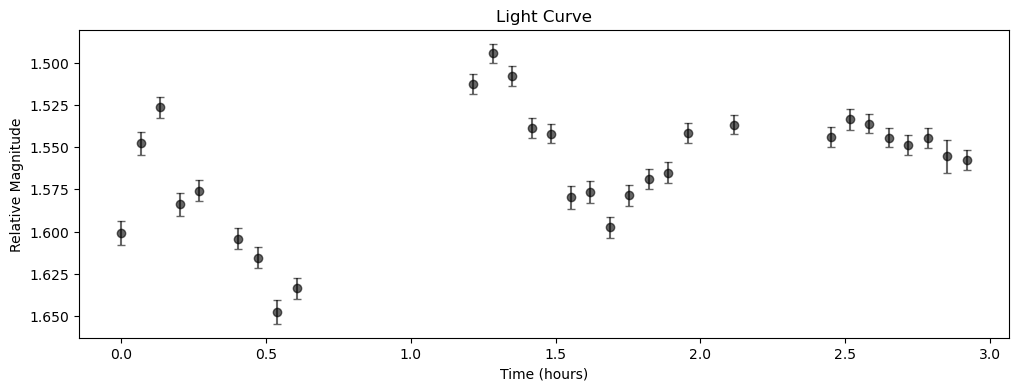

In [11]:
times, times_days, magnitudes, mag_errors = read_data(data_file1)

Lomb-Scargle Best period: 0.0548 days (1.31 hours)
Peak power: 0.4958
Lomb-Scargle Period uncertainty (FWHM): +/- 0.71 hours
False alarm probability: 2.8764e-02
Running burn-in...


100%|██████████| 500/500 [00:01<00:00, 330.64it/s]


Running production...


100%|██████████| 2000/2000 [00:04<00:00, 479.84it/s]



--- MCMC Results ---
Period: 1.29 +0.01 -0.01 hours
Amplitude 1 (fundamental): 0.0342 mag
Amplitude 2 (harmonic): 0.0123 mag


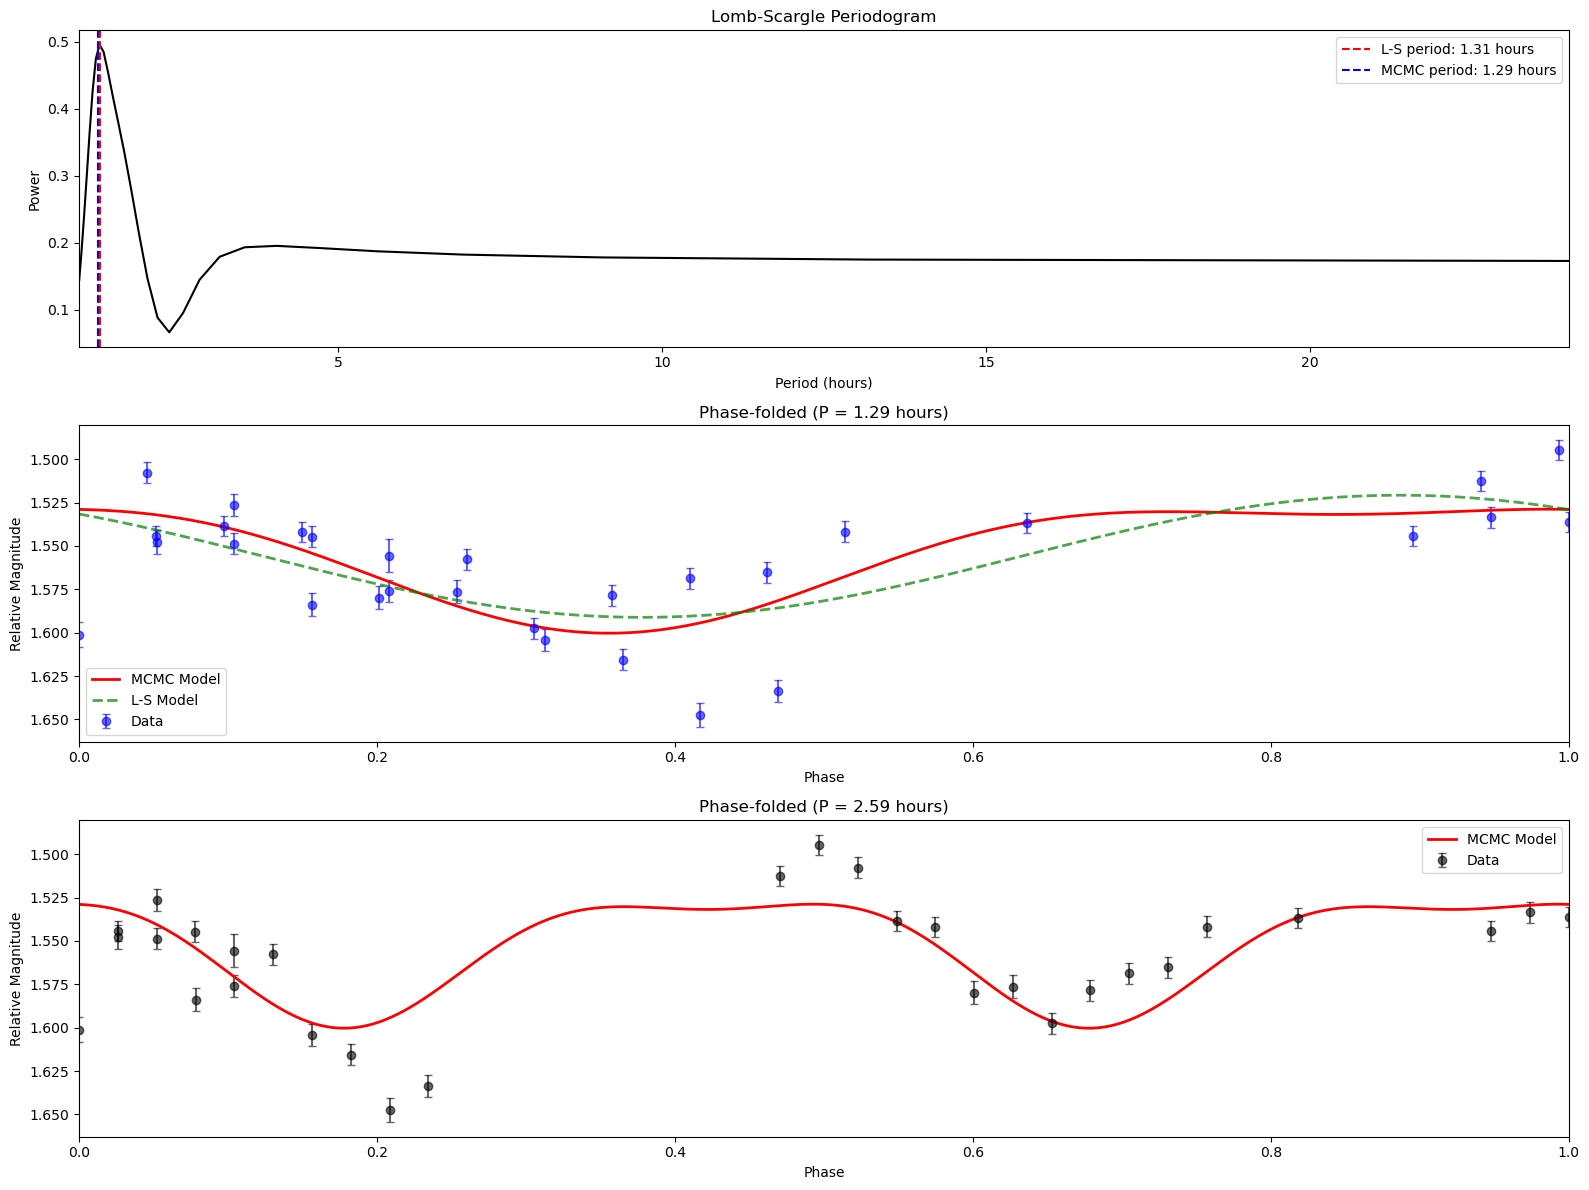

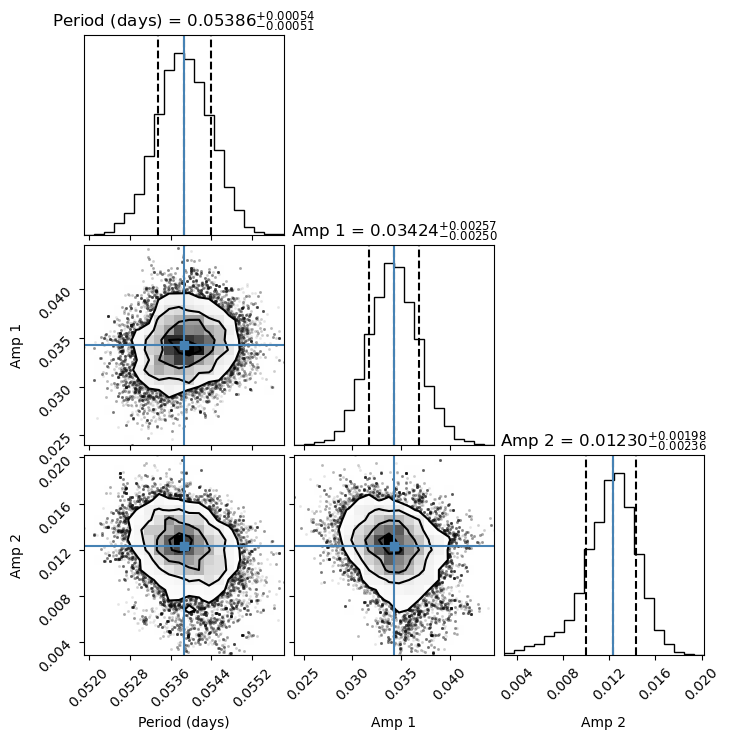

(array([ 0.05385932,  0.03424439,  0.0122977 , -0.68096926, -2.87411147,
         1.55378071]),
 array([[ 0.05388345,  0.03607135,  0.00343907, -0.72824819,  2.57420457,
          1.55321863],
        [ 0.0539836 ,  0.03551093,  0.00773932, -0.75867799, -3.13632585,
          1.55634211],
        [ 0.05354916,  0.03317349,  0.00797521, -0.86181924, -3.11134662,
          1.55634056],
        ...,
        [ 0.05397349,  0.03628206,  0.01129106, -0.63053582,  3.04011007,
          1.55138095],
        [ 0.05338944,  0.03207001,  0.01216517, -0.7247137 ,  3.10436762,
          1.5542011 ],
        [ 0.05393514,  0.03326753,  0.0130619 , -0.81305115, -3.08496886,
          1.55549833]]))

In [12]:
# Run with the first file data
lomb_scargle(times, times_days, magnitudes, mag_errors)

### Now, let's have a look at the second file

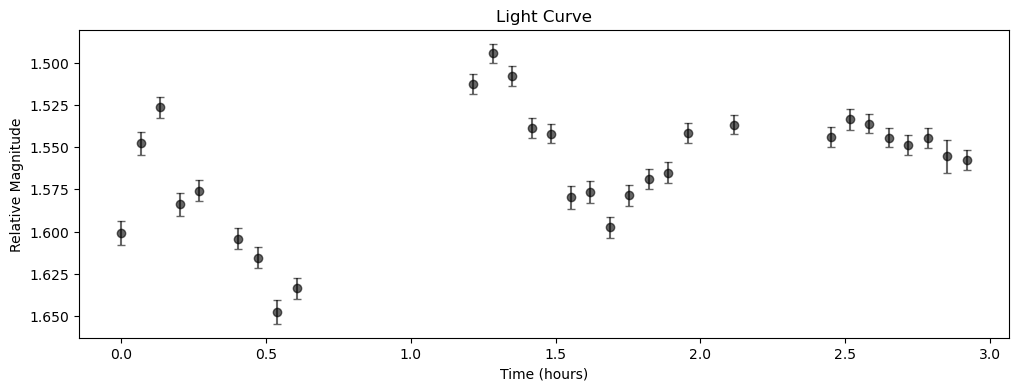

In [13]:
times, times_days, magnitudes, mag_errors = read_data(data_file2)

Lomb-Scargle Best period: 0.0548 days (1.31 hours)
Peak power: 0.4958
Lomb-Scargle Period uncertainty (FWHM): +/- 0.71 hours
False alarm probability: 2.8764e-02
Running burn-in...


100%|██████████| 500/500 [00:00<00:00, 653.65it/s]


Running production...


100%|██████████| 2000/2000 [00:03<00:00, 570.15it/s]



--- MCMC Results ---
Period: 1.30 +0.01 -0.01 hours
Amplitude 1 (fundamental): 0.0337 mag
Amplitude 2 (harmonic): 0.0123 mag


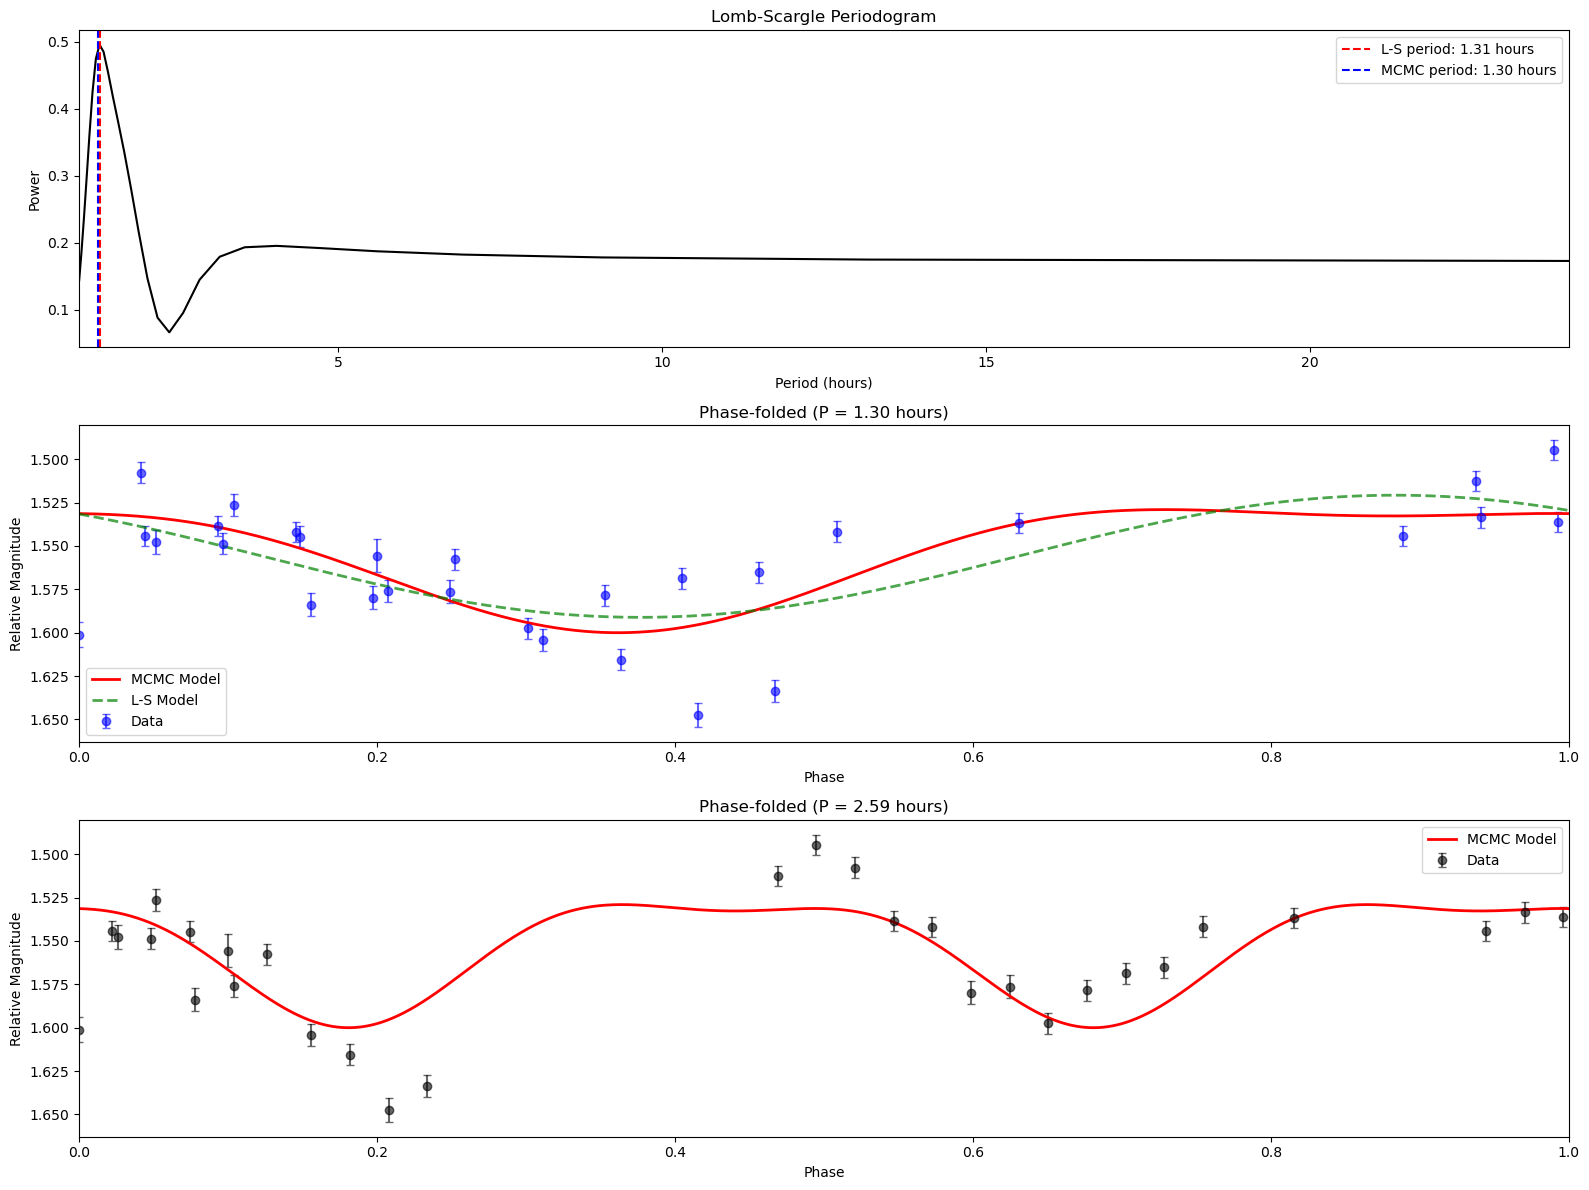

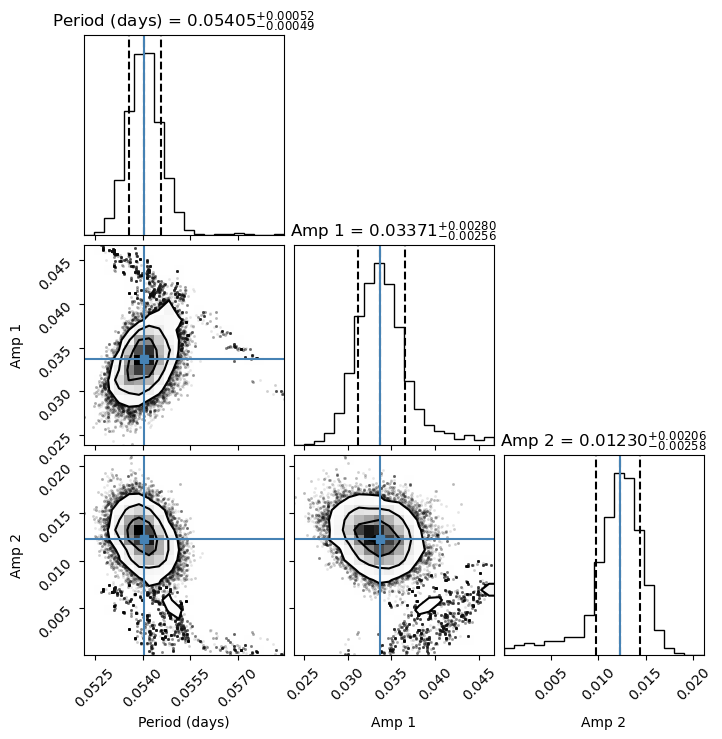

(array([ 0.05405195,  0.03370738,  0.01230285, -0.67474743, -3.01153238,
         1.55404291]),
 array([[ 0.05417804,  0.03522208,  0.01763592, -0.53152148, -3.13847049,
          1.55303492],
        [ 0.0542847 ,  0.03369066,  0.01518951, -0.64626642, -2.99702372,
          1.55466314],
        [ 0.05460062,  0.034217  ,  0.01263656, -0.59298894, -2.88500097,
          1.55453465],
        ...,
        [ 0.05421341,  0.03206293,  0.01452285, -0.57510819, -2.99732081,
          1.55489679],
        [ 0.05360848,  0.03316587,  0.01271904, -0.70073254, -3.11001942,
          1.55496959],
        [ 0.05368303,  0.03577279,  0.0105199 , -0.78064866, -2.98917928,
          1.55605253]]))

In [14]:
lomb_scargle(times, times_days, magnitudes, mag_errors)